# Proceso de Ciencia de Datos Análisis Exploratorio (Data Wrangling)
### Dataset: Hubway (sistema de bicicletas compartidas de Boston, 2011-2013)



Este cuaderno sigue la guía de laboratorio *Análisis Exploratorio de Datos - Data Wrangling*, respondiendo cada
pregunta planteada (Paso 0 a Paso 4) sobre el dataset Hubway, profundizando cada punto con evidencia numérica
extraída directamente de los datos (no solo la estructura del ejercicio de referencia).


In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as sstats

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 20)


In [2]:
# Carga de datos (carpeta local del repositorio: data/)
stations = pd.read_csv("../data/hubway_stations.csv")
trips = pd.read_csv("../data/hubway_trips.csv", low_memory=False)

stations.head()


,id,terminal,station,municipal,lat,lng,status
0,3,B32006,Colleges of the Fenway,Boston,42.340021,-71.100812,Existing
1,4,C32000,Tremont St. at Berkeley St.,Boston,42.345392,-71.069616,Existing
2,5,B32012,Northeastern U / North Parking Lot,Boston,42.341814,-71.090179,Existing
3,6,D32000,Cambridge St. at Joy St.,Boston,42.361285,-71.065140,Existing
4,7,A32000,Fan Pier,Boston,42.353412,-71.044624,Existing


In [3]:
trips.head()

,seq_id,hubway_id,status,duration,start_date,strt_statn,end_date,end_statn,bike_nr,subsc_type,zip_code,birth_date,gender
0,1,8,Closed,9,7/28/2011 10:12:00,23.0,7/28/2011 10:12:00,23.0,B00468,Registered,'97217,1976.0,Male
1,2,9,Closed,220,7/28/2011 10:21:00,23.0,7/28/2011 10:25:00,23.0,B00554,Registered,'02215,1966.0,Male
2,3,10,Closed,56,7/28/2011 10:33:00,23.0,7/28/2011 10:34:00,23.0,B00456,Registered,'02108,1943.0,Male
3,4,11,Closed,64,7/28/2011 10:35:00,23.0,7/28/2011 10:36:00,23.0,B00554,Registered,'02116,1981.0,Female
4,5,12,Closed,12,7/28/2011 10:37:00,23.0,7/28/2011 10:37:00,23.0,B00554,Registered,'97214,1983.0,Female


## Paso 0: Metadata

**Origen:** Hubway fue el sistema público de bicicletas compartidas de Boston (hoy integrado a *Blue Bikes*),
operativo desde julio de 2011. El dataset corresponde a la primera ventana de operación del sistema
(2011-2013) y fue publicado como parte de un data challenge abierto. Fuente de los CSV usados en este cuaderno: [Boston Hubway Data Visualization Challenge Dataset (Kaggle)](https://www.kaggle.com/datasets/codebreaker619/boston-hubway-data-visualization-challenge-dataset).

**Dos tablas relacionadas:**
- `hubway_stations.csv`: catálogo de estaciones físicas (dimensión - *maestro*).
- `hubway_trips.csv`: bitácora de viajes individuales (hechos - *transaccional*), relacionada con
  `stations` mediante `strt_statn` / `end_statn` → `stations.id`.

**Unidad de análisis de cada tabla:**
- En `stations`, un registro es **una estación de anclaje** (dock) en un momento dado.
- En `trips`, un registro es **un viaje individual** (retiro de una bicicleta en una estación y devolución en otra,
  o en la misma).


In [4]:
print("Estaciones:", stations.shape)
print("Viajes:", trips.shape)
print("\nRango temporal de los viajes:")
_start = pd.to_datetime(trips['start_date'], format='%m/%d/%Y %H:%M:%S')
print(_start.min(), "→", _start.max())


Estaciones: (142, 7)
Viajes: (1579025, 13)

Rango temporal de los viajes:
2011-07-28 10:12:00 → 2013-11-30 23:39:00


## Paso 1: Analiza el comportamiento de tus datos

### ¿Cuántos registros hay? ¿Son pocos o demasiados?

`stations` tiene 142 registros un número pequeño, esperable porque describe la infraestructura física
de un solo sistema urbano de bicicletas: no requiere ningún tratamiento especial de escalabilidad.

`trips` tiene ~1.58 millones de registros y ocupa ~700 MB en memoria como `DataFrame` de pandas (con las
columnas de texto sin optimizar). No es "Big Data" en sentido estricto, pero ya no es trivial: cargarlo
completo en memoria es viable en una laptop moderna (8-16 GB RAM), aunque cálculos repetidos (groupby,
joins, gráficos con todos los puntos) se sienten notoriamente más lentos que con un dataset pequeño.
Si el curso pidiera escalarlo (por ejemplo, a los ~10 años completos de Hubway/Blue Bikes), sería el punto
en que convendría pasar a chunking, Dask o Spark.


In [5]:
print("Memoria de trips (MB):", trips.memory_usage(deep=True).sum()/1e6)
print("Memoria de stations (MB):", stations.memory_usage(deep=True).sum()/1e6)


Memoria de trips (MB): 783.376441
Memoria de stations (MB): 0.043683


### ¿Hay datos duplicados?

No se encontraron filas completamente duplicadas en ninguna de las dos tablas, y las llaves primarias
(`stations.id`, `trips.seq_id`, `trips.hubway_id`) son únicas. Sin embargo, aparece una duplicidad **parcial
y con significado real**: 22 estaciones de `stations` comparten el mismo código `terminal` en pares
(una con `status = Removed` y otra con `status = Existing`). Esto no es un error de carga: representa
estaciones que fueron reubicadas/renombradas y reemplazaron una anterior con el mismo poste físico o
código de terminal. Es un dato a tener en cuenta si se usa `terminal` como llave en vez de `id`.


In [6]:
print("Filas duplicadas en stations:", stations.duplicated().sum())
print("Filas duplicadas en trips:", trips.duplicated().sum())
print("id (stations) es única:", stations['id'].is_unique)
print("terminal (stations) es única:", stations['terminal'].is_unique)
print("seq_id (trips) es única:", trips['seq_id'].is_unique)
print("hubway_id (trips) es única:", trips['hubway_id'].is_unique)

dup_terminal = stations[stations.duplicated('terminal', keep=False)].sort_values('terminal')
dup_terminal[['id','terminal','station','status']].head(6)


Filas duplicadas en stations: 0
Filas duplicadas en trips: 0
id (stations) es única: True
terminal (stations) es única: False
seq_id (trips) es única: True
hubway_id (trips) es única: True


,id,terminal,station,status
20,23,B32008,Mayor Thomas M. Menino - Government Center,Removed
95,99,B32008,Mayor Thomas M. Menino - Government Center,Existing
52,56,B32017,Dudley Square,Removed
96,100,B32017,Dudley Square,Existing
10,13,C32002,Boston Medical Center - 721 Mass. Ave.,Removed
98,102,C32002,Boston Medical Center - East Concord at Harri...,Existing


### Tipos de datos por columna, discretos vs. continuos, rangos

**`stations`**
| Columna | Tipo pandas | Naturaleza | Rango / valores |
|---|---|---|---|
| `id` | int | discreta (identificador) | 3 – 145 |
| `terminal` | texto | categórica nominal (código) | 131 valores únicos (142 filas) |
| `station` | texto | categórica nominal (nombre) | — |
| `municipal` | texto | categórica nominal | Boston, Cambridge, Brookline, Somerville |
| `lat`, `lng` | float | continua (coordenada geográfica) | lat ≈ [42.33, 42.40], lng ≈ [-71.15, -71.04] |
| `status` | texto | categórica binaria | Existing / Removed |

**`trips`**
| Columna | Tipo pandas | Naturaleza | Rango / valores |
|---|---|---|---|
| `seq_id`, `hubway_id` | int | discreta (identificador) | — |
| `status` | texto | categórica **constante** | solo `'Closed'` → no aporta información, candidata a eliminar |
| `duration` | int (segundos) | continua | -6900 a 11 994 460 (¡valores imposibles!) |
| `start_date`, `end_date` | texto (debería ser `datetime`) | temporal | 2011-07-28 a 2013-11-30 |
| `strt_statn`, `end_statn` | float (debería ser int/categoría) | discreta (FK a `stations.id`) | 3 – 145, con nulos |
| `bike_nr` | texto | categórica nominal (identificador de bici física) | — |
| `subsc_type` | texto | categórica binaria | Registered / Casual |
| `zip_code` | texto | categórica (código postal, no numérica) | mayoría 5 dígitos, algunos 4 |
| `birth_date` | float (debería ser int/año) | discreta | 1932 – 1995, con muchos nulos |
| `gender` | texto | categórica binaria | Male / Female, con nulos |

**Problemas de formato detectados:**
- `start_date` / `end_date` están como texto, no como `datetime` → hay que convertirlos con `pd.to_datetime`.
- `strt_statn` / `end_statn` están como `float64` solo porque tienen `NaN`; conceptualmente son enteros/categorías (FK).
- `birth_date` es un **año** (no una fecha completa), lo que da una granularidad distinta a `start_date`/`end_date`
  (que sí son timestamp completo con hora y minuto) es decir, el dataset mezcla granularidades temporales
  (año vs. segundo).
- `zip_code` viene con una comilla simple inicial (`'02215`) un artefacto típico de exportación desde Excel
  para evitar que se interprete como número; y 328 registros tienen solo 4 dígitos porque se perdió el cero
  inicial de códigos postales de Massachusetts (ambos son problemas de *formato*, no de valor).
- `duration` está en **segundos**; `lat`/`lng` están en **grados decimales**. No hay conversión de unidades
  pendiente, pero conviene documentarlo porque cualquier fórmula de distancia (Haversine) o de velocidad
  media debe ser consistente con estas unidades.

**Variables categóricas que requerirían codificación numérica para modelado:** `subsc_type`, `gender`,
`municipal`, `status` (stations) y, si se usaran como feature, `station`/`bike_nr` (alta cardinalidad,
mejor tratarlas con *target encoding* o simplemente no usarlas como categoría directa).


In [7]:
print("STATIONS dtypes:\n", stations.dtypes, "\n")
print("TRIPS dtypes:\n", trips.dtypes)


STATIONS dtypes:
 id             int64
terminal      object
station       object
municipal     object
lat          float64
lng          float64
status        object
dtype: object 

TRIPS dtypes:
 seq_id          int64
hubway_id       int64
status         object
duration        int64
start_date     object
strt_statn    float64
end_date       object
end_statn     float64
bike_nr        object
subsc_type     object
zip_code       object
birth_date    float64
gender         object
dtype: object


In [8]:
# Conversión a los tipos correctos (se usará en el resto del análisis)
trips['start_dt'] = pd.to_datetime(trips['start_date'], format='%m/%d/%Y %H:%M:%S')
trips['end_dt']   = pd.to_datetime(trips['end_date'],   format='%m/%d/%Y %H:%M:%S')

print("status(trips) tiene un solo valor:", trips['status'].unique())
print("\nValores únicos por columna clave:")
for c in ['subsc_type','gender']:
    print(f"  {c}: {trips[c].unique()}")

print("\nRangos:")
print("  duration [s]:", trips['duration'].min(), "a", trips['duration'].max())
print("  strt_statn:", trips['strt_statn'].min(), "a", trips['strt_statn'].max())
print("  birth_date:", trips['birth_date'].min(), "a", trips['birth_date'].max())

print("\nEjemplo de zip_code (formato con comilla y longitud variable):")
zc = trips['zip_code'].dropna().str.replace("'", "")
print(zc.head(5).tolist(), "| longitudes:", zc.str.len().value_counts().to_dict())


status(trips) tiene un solo valor: ['Closed']

Valores únicos por columna clave:
  subsc_type: ['Registered' 'Casual']
  gender: ['Male' 'Female' nan]

Rangos:
  duration [s]: -6900 a 11994458
  strt_statn: 3.0 a 145.0
  birth_date: 1932.0 a 1995.0

Ejemplo de zip_code (formato con comilla y longitud variable):
['97217', '02215', '02108', '02116', '97214'] | longitudes: {5: 1105931, 4: 328}


### ¿Qué representa un registro? ¿Hay niveles de granularidad?

Cada fila de `trips` es **un viaje cerrado** (`status == 'Closed'` en el 100% de los casos, por eso esa
columna no discrimina nada y puede descartarse del análisis). Un viaje queda definido por: quién lo hizo
(atributos demográficos, cuando existen), qué bicicleta usó, dónde empezó y terminó, y cuánto duró.

No es un problema con clases balanceadas de forma nativa (no es un dataset "etiquetado" para clasificación
por diseño), pero contiene una columna binaria natural, `subsc_type`, que puede leerse como una etiqueta:
*Registered* (usuario con membresía, ~70% de los viajes) vs. *Casual* (usuario ocasional/turista, ~30%).

Niveles de granularidad presentes en los datos:
- **Espacial:** estación (`strt_statn`/`end_statn`) → municipio (`municipal`) → coordenadas exactas (`lat`,`lng`).
- **Temporal:** año, mes, día de la semana, hora, minuto (derivables de `start_dt`); `birth_date` en cambio
  solo tiene granularidad de **año**.


### ¿Están todas las filas completas o hay campos nulos?

`stations` no tiene ningún valor nulo. `trips` sí, y de forma muy desigual entre columnas:


In [9]:
nulos = trips.isna().sum().sort_values(ascending=False)
pct = (nulos / len(trips) * 100).round(2)
pd.DataFrame({'nulos': nulos, '% del total': pct})


,nulos,% del total
birth_date,1228381,77.79
zip_code,472766,29.94
gender,472611,29.93
bike_nr,466,0.03
end_statn,45,0.00
strt_statn,14,0.00
seq_id,0,0.00
hubway_id,0,0.00
status,0,0.00
duration,0,0.00


**¿Son demasiados nulos? ¿Queda el resto de información inútil?**

`birth_date` (77.8%) y `gender` (29.9%) tienen muchísimos nulos a primera vista parecería que hay que
descartar esas columnas. Pero al cruzar los nulos con `subsc_type` aparece un patrón que **no es aleatorio**:


In [10]:
print("Fracción de nulos en birth_date, por tipo de suscripción:")
print(trips.groupby('subsc_type')['birth_date'].apply(lambda s: s.isna().mean()))
print("\nFracción de nulos en gender, por tipo de suscripción:")
print(trips.groupby('subsc_type')['gender'].apply(lambda s: s.isna().mean()))


Fracción de nulos en birth_date, por tipo de suscripción:
subsc_type
Casual        1.000000
Registered    0.683081
Name: birth_date, dtype: float64

Fracción de nulos en gender, por tipo de suscripción:
subsc_type
Casual        1.0
Registered    0.0
Name: gender, dtype: float64


El 100% de los usuarios **Casual** no tiene `birth_date` ni `gender` registrados: no es un dato faltante
por error, es *missing by design* el sistema simplemente no le pide esos datos a quien compra un pase de
un solo día. Es decir, los nulos codifican información (aproximan el propio `subsc_type`), y **no** deben
imputarse con la media/moda como si fueran aleatorios.

Además, incluso entre los usuarios *Registered* (que sí deberían tener estos datos) hay un patrón temporal:


In [11]:
trips['year'] = trips['start_dt'].dt.year
reg = trips[trips['subsc_type'] == 'Registered']
print("Fracción de nulos en birth_date (solo Registered), por año:")
print(reg.groupby('year')['birth_date'].apply(lambda s: s.isna().mean()).round(3))


Fracción de nulos en birth_date (solo Registered), por año:
year
2011    0.011
2012    0.257
2013    1.000
Name: birth_date, dtype: float64


En 2013 el 100% de los viajes de usuarios *Registered* tiene `birth_date` nulo, cuando en 2011 solo el 1%
lo tenía. Esto indica un **cambio en el proceso de captura de datos** a partir de cierto momento (posible
cambio de sistema o de formulario de registro), no un problema aleatorio de calidad. Es un hallazgo
importante para Paso 4: cualquier análisis demográfico (edad, género) queda **sesgado hacia 2011-2012**, y no
puede extrapolarse a 2013 sin advertirlo.

**Conclusión sobre nulos:** no se elimina la columna, pero tampoco se imputan como si faltaran al azar.
Se documenta el mecanismo y se usan solo en el subconjunto donde existen, con esa limitación explícita.

Los nulos en `strt_statn` (14), `end_statn` (45) y `bike_nr` (466) sí son minoría y parecen errores de
captura reales; se pueden descartar sin afectar el resto del análisis.


In [12]:
print("Filas afectadas por nulos 'menores' (no relacionados a subsc_type):")
print("  strt_statn:", trips['strt_statn'].isna().sum())
print("  end_statn:", trips['end_statn'].isna().sum())
print("  bike_nr:", trips['bike_nr'].isna().sum())
print("Duración de los viajes con bike_nr nulo (¿son viajes raros?):")
trips.loc[trips['bike_nr'].isna(), 'duration'].describe()


Filas afectadas por nulos 'menores' (no relacionados a subsc_type):
  strt_statn: 14
  end_statn: 45
  bike_nr: 466
Duración de los viajes con bike_nr nulo (¿son viajes raros?):


count       466.000000
mean       2686.967811
std       13005.487457
min           8.000000
25%         498.500000
50%         874.000000
75%        1566.500000
max      251877.000000
Name: duration, dtype: float64

### ¿Siguen alguna distribución? Medidas de tendencia central

`describe()` de las variables numéricas principales:


In [13]:
stations[['lat','lng']].describe()

,lat,lng
count,142.000000,142.000000
mean,42.354820,-71.089087
std,0.020089,0.027111
min,42.309467,-71.146452
25%,42.341652,-71.113183
50%,42.353373,-71.089191
75%,42.366265,-71.065210
max,42.404490,-71.035705


In [14]:
trips[['duration']].describe()

,duration
count,1.579025e+06
mean,1.200280e+03
std,2.653539e+04
min,-6.900000e+03
25%,4.120000e+02
50%,6.600000e+02
75%,1.082000e+03
max,1.199446e+07


In [15]:
trips['age'] = trips['year'] - trips['birth_date']
trips.loc[trips['gender'].notna(), 'age'].describe()


count    350644.000000
mean         35.480228
std          10.988335
min          17.000000
25%          27.000000
50%          32.000000
75%          43.000000
max          79.000000
Name: age, dtype: float64

`duration` está lejísimos de una distribución simétrica: la media (1200 s ≈ 20 min) es casi el doble de
la mediana (660 s = 11 min), y la asimetría (skewness) es enorme. Eso ya anuncia un problema de outliers
severo en el Paso 2. Para verlo mejor, además de la media aritmética conviene comparar con la media
geométrica y armónica (ambas son menos sensibles a valores extremos hacia arriba):


In [16]:
dur_pos = trips.loc[trips['duration'] > 0, 'duration']
print("Media aritmética :", round(dur_pos.mean(), 1), "s")
print("Mediana           :", dur_pos.median(), "s")
print("Moda              :", dur_pos.mode().iloc[0], "s")
print("Media geométrica  :", round(sstats.gmean(dur_pos), 1), "s")
print("Media armónica    :", round(sstats.hmean(dur_pos), 1), "s")
print("Desv. estándar    :", round(dur_pos.std(), 1), "s")
print("Asimetría (skew)  :", round(dur_pos.skew(), 2))


Media aritmética : 1203.8 s
Mediana           : 660.0 s
Moda              : 360 s
Media geométrica  : 678.2 s
Media armónica    : 452.1 s
Desv. estándar    : 26572.6 s
Asimetría (skew)  : 310.91


La media geométrica (678 s) y armónica (452 s) están mucho más cerca de la mediana que la media aritmética
(1200 s): confirma que unos pocos viajes extremadamente largos "jalan" la media aritmética hacia arriba, y
que un viaje típico de Hubway dura entre 7 y 12 minutos, consistente con su diseño (viajes cortos tipo
"última milla", no alquileres turísticos de todo el día).

`age`, en cambio, sí se ve razonablemente simétrica y acotada de forma natural (17 a 79 años, sin que haga
falta filtrar nada), típica de una población adulta urbana que usa bicicletas para transporte.


### ¿Hay correlación entre variables?

Correlación de Pearson entre las variables numéricas continuas disponibles a nivel de viaje:


In [17]:
num = trips[['duration', 'age', 'strt_statn', 'end_statn']]
corr = num.corr()
corr


,duration,age,strt_statn,end_statn
duration,1.000000,0.002557,-0.004851,-0.005898
age,0.002557,1.000000,-0.032376,-0.026092
strt_statn,-0.004851,-0.032376,1.000000,0.340437
end_statn,-0.005898,-0.026092,0.340437,1.000000


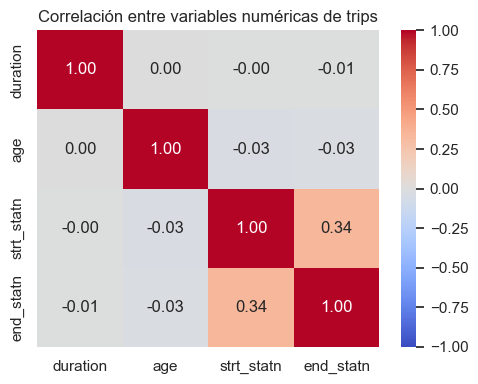

In [18]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre variables numéricas de trips")
plt.tight_layout()
plt.savefig("../report/figures/fig05_correlacion_heatmap.png", dpi=150)
plt.show()


No hay correlaciones lineales fuertes: `duration` no depende linealmente de la edad ni de la estación de
origen/destino (r ≈ 0). La única correlación moderada es entre `strt_statn` y `end_statn` (r ≈ 0.34): tiene
sentido, porque los identificadores de estación cercanas geográficamente tienden a ser numéricamente
próximos (el sistema fue numerando estaciones a medida que se instalaban por zonas), no porque una
estación "cause" a la otra. Esto es un buen recordatorio de que correlación entre IDs numéricos rara vez
es sustantiva y debe interpretarse con cuidado.


## Paso 2: Análisis de outliers

Usamos el criterio de rango intercuartílico (IQR) sobre `duration`, la variable con la distribución más
problemática.


In [19]:
q1, q3 = trips['duration'].quantile([.25, .75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Límite superior (outlier): {upper} s (~{upper/60:.1f} min)")
print(f"Límite inferior (outlier): {lower} s")

n_out_sup = (trips['duration'] > upper).sum()
n_out_inf = (trips['duration'] < 0).sum()
n_24h = (trips['duration'] > 86400).sum()
print(f"\nOutliers por encima del límite superior: {n_out_sup} ({n_out_sup/len(trips)*100:.2f}% del total)")
print(f"Duraciones negativas (imposibles): {n_out_inf}")
print(f"Viajes de más de 24 horas: {n_24h}")
print(f"Duración máxima registrada: {trips['duration'].max()} s (~{trips['duration'].max()/86400:.1f} días)")


Q1=412.0, Q3=1082.0, IQR=670.0
Límite superior (outlier): 2087.0 s (~34.8 min)
Límite inferior (outlier): -593.0 s

Outliers por encima del límite superior: 104385 (6.61% del total)
Duraciones negativas (imposibles): 49
Viajes de más de 24 horas: 571
Duración máxima registrada: 11994458 s (~138.8 días)


**¿Son errores de carga o son reales?** Hay dos grupos distintos de outliers, con explicaciones distintas:

1. **Duraciones negativas (49 filas) y duraciones de 0 segundos (4389 filas):** son físicamente imposibles
   (un viaje no puede durar menos de 0 s, y uno de 0 s probablemente es un usuario que retira y devuelve la
   bici de inmediato, o un error de sensor/reloj de la estación). Son errores de carga / de sensor: se
   pueden eliminar sin remordimiento.
2. **Duraciones extremadamente largas (6.6% de los viajes, algunas de varios días):** Hubway (como la
   mayoría de sistemas bike-share) cobra tarifas crecientes después de los primeros 30-60 minutos
   precisamente para desincentivar quedarse con la bici mucho tiempo; una duración de días normalmente
   significa que la bicicleta fue robada, perdida, o que el usuario nunca hizo *check-in* de devolución (y el
   sistema cerró el viaje automáticamente tras un timeout). **Estos no son errores de carga: son eventos
   reales del negocio**, y conviene conservarlos en un análisis operativo (pérdida de flota, mantenimiento),
   pero **excluirlos** de cualquier análisis de "duración típica de un viaje" o de un modelo de tiempo de
   viaje, porque distorsionan por completo media y varianza.

**Decisión adoptada para el resto del cuaderno:** se conserva el dataset completo para conteos (Paso 1,
Paso 3 categóricas), pero se usa un subconjunto `trips_dur_ok` (duración > 0 y ≤ límite IQR superior, o como
alternativa más permisiva, ≤ 24h) para cualquier estadística o gráfico centrado en la duración del viaje.


In [20]:
trips_dur_ok = trips[(trips['duration'] > 0) & (trips['duration'] <= 86400)].copy()
print("Filas originales:", len(trips), "→ filas tras filtrar outliers extremos de duración:", len(trips_dur_ok))
print(f"Se descartó el {(1 - len(trips_dur_ok)/len(trips))*100:.2f}% de los viajes para este subconjunto.")


Filas originales: 1579025 → filas tras filtrar outliers extremos de duración: 1574016
Se descartó el 0.32% de los viajes para este subconjunto.


## Paso 3: Visualización

Variables categóricas → gráfico de barras / circular. Variables numéricas → histograma (una variable) y
boxplot (dos variables). Se agrega un scatterplot para relación entre variables continuas.


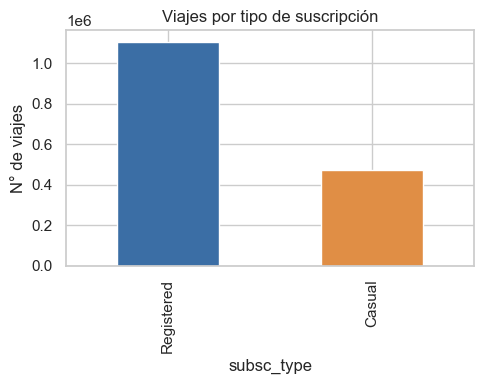

In [21]:
# Gráfico de barras: subsc_type
fig, ax = plt.subplots(figsize=(5,4))
trips['subsc_type'].value_counts().plot(kind='bar', ax=ax, color=['#3b6ea5','#e08e45'])
ax.set_title("Viajes por tipo de suscripción")
ax.set_ylabel("N° de viajes")
plt.tight_layout()
plt.savefig("../report/figures/fig01_barras_subsc_type.png", dpi=150)
plt.show()


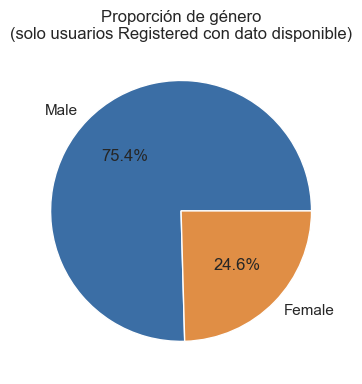

In [22]:
# Gráfico circular: proporción de género (solo donde está registrado)
fig, ax = plt.subplots(figsize=(4,4))
trips['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=['#3b6ea5','#e08e45'])
ax.set_ylabel("")
ax.set_title("Proporción de género\n(solo usuarios Registered con dato disponible)")
plt.tight_layout()
plt.savefig("../report/figures/fig02_circular_genero.png", dpi=150)
plt.show()


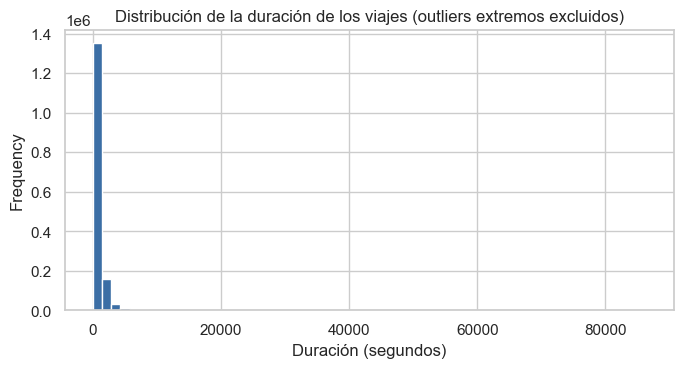

In [23]:
# Histograma: duración del viaje (subconjunto sin outliers extremos)
fig, ax = plt.subplots(figsize=(7,4))
trips_dur_ok['duration'].plot(kind='hist', bins=60, ax=ax, color='#3b6ea5')
ax.set_xlabel("Duración (segundos)")
ax.set_title("Distribución de la duración de los viajes (outliers extremos excluidos)")
plt.tight_layout()
plt.savefig("../report/figures/fig03_histograma_duracion.png", dpi=150)
plt.show()


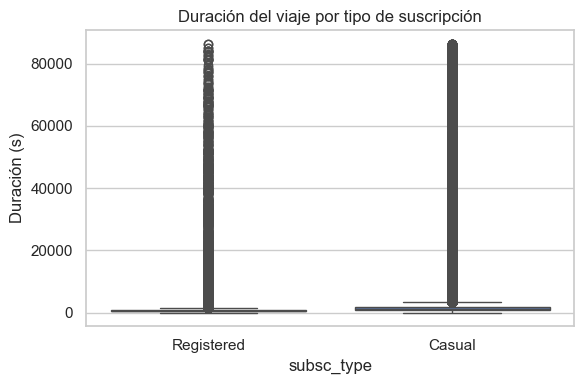

In [24]:
# Boxplot: duración por tipo de suscripción
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=trips_dur_ok, x='subsc_type', y='duration', ax=ax)
ax.set_title("Duración del viaje por tipo de suscripción")
ax.set_ylabel("Duración (s)")
plt.tight_layout()
plt.savefig("../report/figures/fig04_boxplot_duracion_subsc.png", dpi=150)
plt.show()


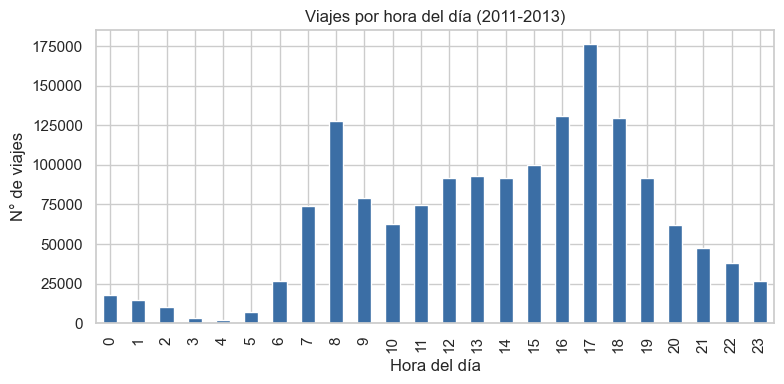

In [25]:
# Uso por hora del día (patrón temporal)
fig, ax = plt.subplots(figsize=(8,4))
trips['start_dt'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=ax, color='#3b6ea5')
ax.set_xlabel("Hora del día")
ax.set_ylabel("N° de viajes")
ax.set_title("Viajes por hora del día (2011-2013)")
plt.tight_layout()
plt.savefig("../report/figures/fig06_viajes_por_hora.png", dpi=150)
plt.show()


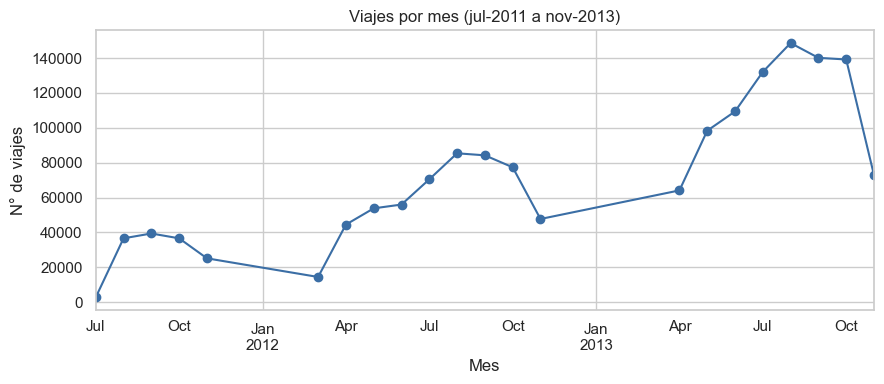

In [26]:
# Uso por mes/año (estacionalidad)
fig, ax = plt.subplots(figsize=(9,4))
trips.groupby(trips['start_dt'].dt.to_period('M')).size().plot(ax=ax, marker='o', color='#3b6ea5')
ax.set_xlabel("Mes")
ax.set_ylabel("N° de viajes")
ax.set_title("Viajes por mes (jul-2011 a nov-2013)")
plt.tight_layout()
plt.savefig("../report/figures/fig07_viajes_por_mes.png", dpi=150)
plt.show()


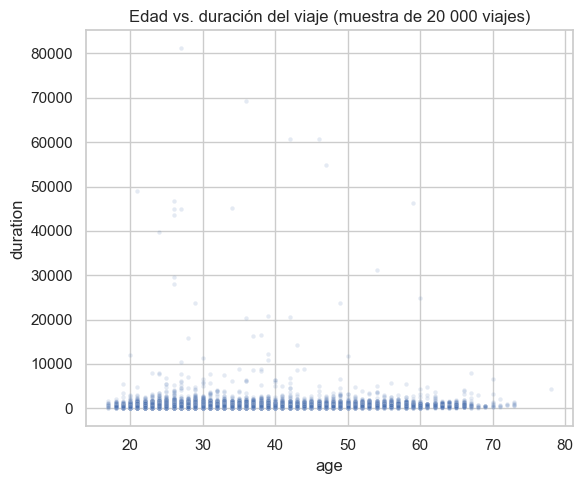

In [27]:
# Scatterplot: edad vs. duración (relación entre dos variables continuas)
muestra = trips_dur_ok.dropna(subset=['age']).sample(20000, random_state=42)
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=muestra, x='age', y='duration', alpha=0.15, s=10, ax=ax)
ax.set_title("Edad vs. duración del viaje (muestra de 20 000 viajes)")
plt.tight_layout()
plt.savefig("../report/figures/fig08_scatter_edad_duracion.png", dpi=150)
plt.show()


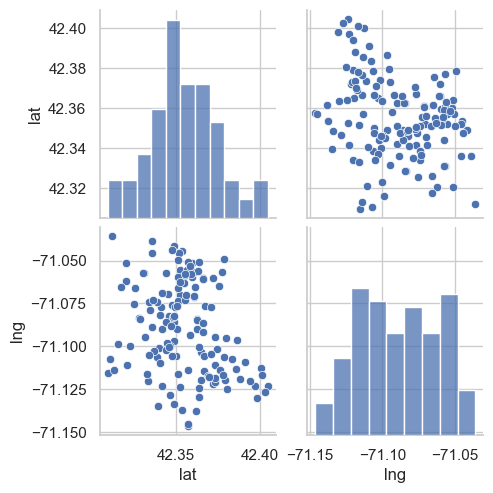

In [28]:
# Pairplot de stations, como en el ejercicio de referencia
sns.pairplot(stations[['lat','lng']])
plt.savefig("../report/figures/fig09_pairplot_stations.png", dpi=150)
plt.show()


**Lecturas de las visualizaciones:**
- El sistema tiene ~2.3 veces más viajes *Registered* que *Casual*, y entre quienes reportan género hay una
  proporción notablemente mayor de hombres (~75%).
- El histograma de duración confirma la asimetría a la derecha incluso después de quitar los outliers más
  extremos: la mayoría de viajes dura entre 5 y 15 minutos.
- El boxplot muestra que los usuarios *Casual* tienden a viajes más largos y con más dispersión que los
  *Registered* coherente con que un turista/ocasional pasea más tiempo, mientras que un suscriptor usa la
  bici como transporte punto a punto.
- El uso por hora tiene **dos picos claros** (≈8am y ≈17-18h): el patrón típico de un desplazamiento de ida y
  vuelta al trabajo/estudio (commute), evidencia de que el uso dominante es utilitario, no recreativo.
- El uso por mes muestra **estacionalidad fuerte**: el servicio se detiene por completo en los meses de
  invierno (diciembre-febrero no aparecen) y crece cada verano boreal es un patrón dependiente del clima,
  no del comportamiento del usuario en sí.
- El pairplot de `lat`/`lng` de las estaciones no muestra una relación lineal simple entre ambas coordenadas:
  la forma alargada refleja la geografía real de Boston/Cambridge a lo largo del río Charles, no una
  correlación estadística "verdadera".


## Paso 4: Encuentra un problema potencial en tus datos

**Pregunta con componente tiempo-espacio (dataset externo sugerido):** *¿El clima (temperatura, lluvia,
nieve) explica las caídas y picos de uso día a día, más allá del patrón estacional agregado por mes?*
Para responderla haría falta cruzar `trips` (agregado por día) con un dataset externo de clima histórico de
Boston (NOAA Climate Data Online, dataset GHCN-Daily, estación Boston Logan Airport `USW00014739`, https://www.ncdc.noaa.gov/cdo-web/datasets o, sin necesidad de registro, Open-Meteo Historical Weather API), uniendo por la fecha (`start_dt.dt.date`). Es exactamente el tipo de enriquecimiento que
pide el Paso 4: uno de los datasets (clima) aporta la dimensión *tiempo*, y las coordenadas de las estaciones
aportan la dimensión *espacio* (se podría, además, cruzar con datos de tráfico o de la red de transporte
público del MBTA para ver sustitución/complementariedad modal).

**Si se planteara como problema supervisado predecir `subsc_type` (Registered vs. Casual):**
- **Columna de salida:** `subsc_type`, **binaria**.
- **¿Está balanceado?** No exactamente: 70% Registered / 30% Casual. No es un desbalance extremo, pero sí
  conviene reportar F1/recall por clase y no solo accuracy.
- **Features candidatas:** hora del día y día de la semana (los patrones de commute vistos en Paso 3 son
  muy distintos entre ambos grupos), duración del viaje, estación de origen/destino (turistas concentrados
  en pocas estaciones cerca de atracciones), y estacionalidad (mes).
- **Features a descartar:** `birth_date` y `gender` **no pueden usarse como feature real** como se vio en
  Paso 1, son nulos en el 100% de los Casual *por definición*, así que usarlas sería filtrar la respuesta
  (data leakage): el modelo "aprendería" a predecir Casual simplemente viendo que faltan esos datos, lo cual
  no generaliza a un escenario donde se quisiera predecir el tipo de usuario a partir de su comportamiento.
- **¿Es un problema dependiente del tiempo (TimeSeries)?** Sí, en el sentido de que la composición de
  usuarios y el volumen total cambian con la estación del año; un modelo entrenado solo con datos de verano
  no necesariamente generaliza a los meses de transición (abril, noviembre).

**Problemas notables de calidad de datos ya identificados:** el cambio abrupto de política de captura de
`birth_date`/`gender` en 2013 (Paso 1), las duraciones imposibles (negativas o de varios días) y el
artefacto de formato en `zip_code`.

**Relación sorprendente:** la falta de dato demográfico no es ruido aleatorio, sino que **codifica** el tipo
de usuario un ejemplo claro de que en datos reales "nulo" puede ser, en sí mismo, información útil en
lugar de algo que simplemente se deba imputar o descartar.


### Extensión: cruce real con clima externo (Open-Meteo)

Las celdas siguientes bajan clima diario de Boston vía la API pública de **Open-Meteo** (sin token) y lo
cruzan con el número de viajes por día, para responder de forma concreta la pregunta tiempo-espacio
planteada arriba. *(Requiere acceso a internet al ejecutar el notebook no se ejecutó en este entorno de
generación por no tener salida a `archive-api.open-meteo.com`; correrlo localmente o en Colab.)*


In [29]:
import requests

resp = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
    "latitude": 42.355, "longitude": -71.065,  # centro de Boston
    "start_date": "2011-07-28", "end_date": "2013-11-30",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum",
    "timezone": "America/New_York",
})
clima = pd.DataFrame(resp.json()["daily"])
clima["time"] = pd.to_datetime(clima["time"]).dt.date
clima.head()


,time,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum
0,2011-07-28,26.0,18.1,0.0,0.0
1,2011-07-29,27.2,19.2,1.7,0.0
2,2011-07-30,31.0,22.0,1.7,0.0
3,2011-07-31,30.5,18.8,0.0,0.0
4,2011-08-01,31.9,20.2,0.0,0.0


In [30]:
viajes_por_dia = (
    trips.assign(fecha=trips['start_dt'].dt.date)
         .groupby('fecha').size()
         .rename('n_viajes')
         .reset_index()
)

clima_viajes = viajes_por_dia.merge(clima, left_on='fecha', right_on='time', how='inner')
clima_viajes[['fecha','n_viajes','temperature_2m_max','precipitation_sum','snowfall_sum']].head()


,fecha,n_viajes,temperature_2m_max,precipitation_sum,snowfall_sum
0,2011-07-28,424,26.0,0.0,0.0
1,2011-07-29,536,27.2,1.7,0.0
2,2011-07-30,800,31.0,1.7,0.0
3,2011-07-31,1007,30.5,0.0,0.0
4,2011-08-01,788,31.9,0.0,0.0


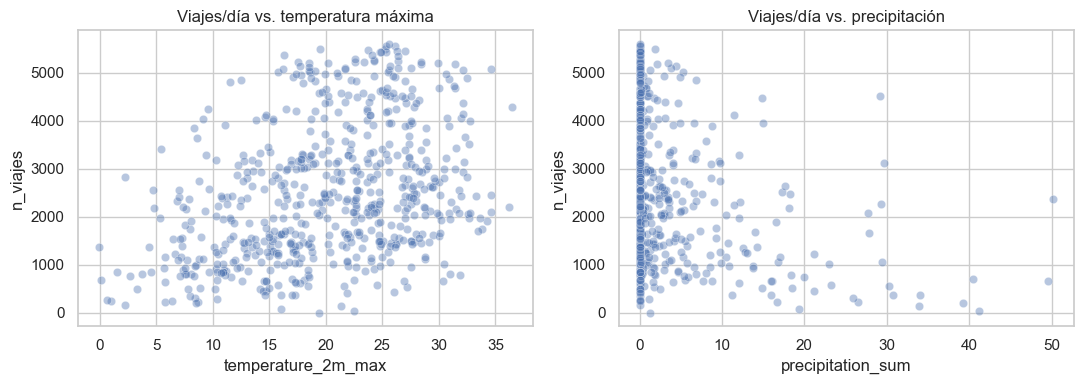

Correlación viajes/día vs. temperatura máxima: 0.36791215000373423
Correlación viajes/día vs. precipitación: -0.2662549087734317


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.scatterplot(data=clima_viajes, x='temperature_2m_max', y='n_viajes', alpha=0.4, ax=axes[0])
axes[0].set_title("Viajes/día vs. temperatura máxima")
sns.scatterplot(data=clima_viajes, x='precipitation_sum', y='n_viajes', alpha=0.4, ax=axes[1])
axes[1].set_title("Viajes/día vs. precipitación")
plt.tight_layout()
plt.savefig("../report/figures/fig10_clima_vs_viajes.png", dpi=150)
plt.show()

print("Correlación viajes/día vs. temperatura máxima:",
      clima_viajes['n_viajes'].corr(clima_viajes['temperature_2m_max']))
print("Correlación viajes/día vs. precipitación:",
      clima_viajes['n_viajes'].corr(clima_viajes['precipitation_sum']))


## Conclusión

El dataset Hubway es de tamaño moderado (no requiere Big Data tooling), con una tabla de estaciones limpia
y una de viajes con problemas de calidad reales y bien identificables: outliers de duración con dos causas
distintas (errores de sensor vs. eventos reales de bicicletas perdidas/robadas), y un patrón de nulos que no
es aleatorio sino estructural (usuarios *Casual* nunca reportan datos demográficos, y la captura de esos
datos cambió de política en 2013). El comportamiento de uso es claramente utilitario y estacional: dos
picos horarios de commute y una fuerte caída en invierno. Estos hallazgos más que cualquier estadística
descriptiva aislada son los que deberían guiar cualquier modelado posterior: qué variables son seguras de
usar como *feature*, cuáles filtrarían la respuesta (`birth_date`, `gender`), y qué subconjunto de datos usar
según la pregunta (todo el dataset para conteos, el subconjunto sin outliers extremos para duración).
